In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [6]:
## thsi csv is imbalance 
# either good or pooor 


In [9]:
df = pd.read_csv("winequality-red.csv", sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [11]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [12]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [17]:
df['quality'].describe()

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

In [18]:
df['quality'].head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [37]:
df['target'] = (df['quality'] > 7). astype(int)

KeyError: 'quality'

In [28]:
df['target'].head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [29]:
df.drop('quality', axis =1, inplace= True)


In [30]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [32]:
print(df['target'].value_counts())

target
0    1581
1      18
Name: count, dtype: int64


In [38]:
X = df.drop('target', axis = 1)
Y = df['target']

In [41]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y , test_size =0.3, random_state=42, stratify=Y)

In [43]:
rf = RandomForestClassifier(
    n_estimators = 100,   # number of tree
    max_depth = None,      # there is no limit on depth
    max_features = 'sqrt',  # ^p features at each spilt
    random_state = 42,
    oob_score = True   # enable out of bag score

)

In [44]:
rf.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [46]:
print ( " OOB score :", rf.oob_score_)

 OOB score : 0.9883824843610366


In [47]:
Y_pred = rf.predict(X_test)
Y_proba = rf.predict_proba(X_test)[:,1]   #   probality for roc auc

In [48]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       475
           1       1.00      0.20      0.33         5

    accuracy                           0.99       480
   macro avg       1.00      0.60      0.66       480
weighted avg       0.99      0.99      0.99       480



In [49]:
print("ROC_AOUC score :", roc_auc_score( Y_test, Y_proba))

ROC_AOUC score : 0.8959999999999999


In [52]:
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending = False )


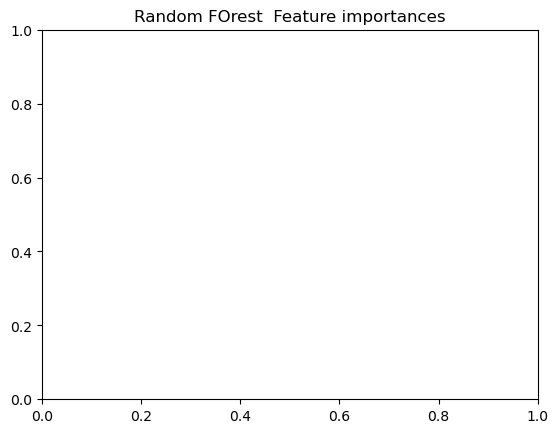

In [53]:
sns.barplot(X=  feat_importances.values , Y = feat_importances.index)
plt.title("Random FOrest  Feature importances")
plt.show()

In [ ]:
# HYper paramter tunning 

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [None, 10,20],
    'min_samples_split':[2,5]
}


In [60]:
grid = GridSearchCV(RandomForestClassifier(random_state = 42), param_grid,
                    cv= 3, scoring = 'roc_auc', n_jobs = -1)
grid.fit(X_train,Y_train )
print("Best Params :", grid.best_params_)
print("Best AUC score :", grid.best_score_)                    

Best Params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best AUC score : 0.8765241447704333


In [61]:
# smote resampling techniwyue 

print(df['target']. value_counts())

target
0    1581
1      18
Name: count, dtype: int64


In [ ]:
pip install 